# Chapter 8: Tree-Based Algorithms and Ensemble Methods

## 📋 Summary

Decision trees and ensemble methods form the backbone of modern tabular ML. A single decision tree is highly interpretable but prone to overfitting. Ensemble methods — **bagging** (Random Forests) and **boosting** (Gradient Boosting) — combine many trees to dramatically reduce variance and improve accuracy.

This chapter covers decision tree construction, random forests and bagging, gradient boosting machines (GBM), hyperparameter tuning for tree-based models, and comparing ensemble methods.

---

## 🧠 Theoretical Explanation

### Decision Trees
A decision tree recursively splits the feature space using binary rules to minimize impurity. Two impurity measures:
- **Gini impurity**: `G = 1 - Σpi²` — probability that a randomly chosen sample would be incorrectly labeled
- **Entropy**: `H = -Σpi·log(pi)` — information-theoretic measure of disorder

The tree grows by finding the split that maximizes **information gain** (reduction in impurity). Trees are prone to overfitting — controlled by `max_depth`, `min_samples_split`, etc.

### Bagging and Random Forests
**Bagging** (Bootstrap Aggregating):
1. Sample N subsets of the data with replacement (bootstrap)
2. Train a decision tree on each subset
3. Average predictions (regression) or majority vote (classification)

**Random Forests** add extra randomness: at each split, only a random subset of `max_features` features are considered. This decorrelates the trees, reducing variance further.

### Gradient Boosting
Instead of training trees independently (like bagging), gradient boosting trains trees **sequentially**, where each tree corrects the errors of the previous one:
1. Initialize with a simple model (e.g., mean)
2. Compute residuals (pseudo-gradients of the loss)
3. Fit a tree to the residuals
4. Update the model: `F_new = F_old + learning_rate × tree`
5. Repeat

Key hyperparameters: `n_estimators`, `learning_rate`, `max_depth`, `subsample`.

### Feature Importance
Tree-based models provide `feature_importances_` — the average decrease in impurity from splits using each feature. Useful for feature selection.


## 8.1 Decision Trees

In [1]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# Train a shallow tree (depth=3 for interpretability)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

print(f'Decision Tree accuracy: {accuracy_score(y_test, dt.predict(X_test)):.4f}')
print('\nTree structure:')
print(export_text(dt, feature_names=iris.feature_names))

Decision Tree accuracy: 1.0000

Tree structure:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



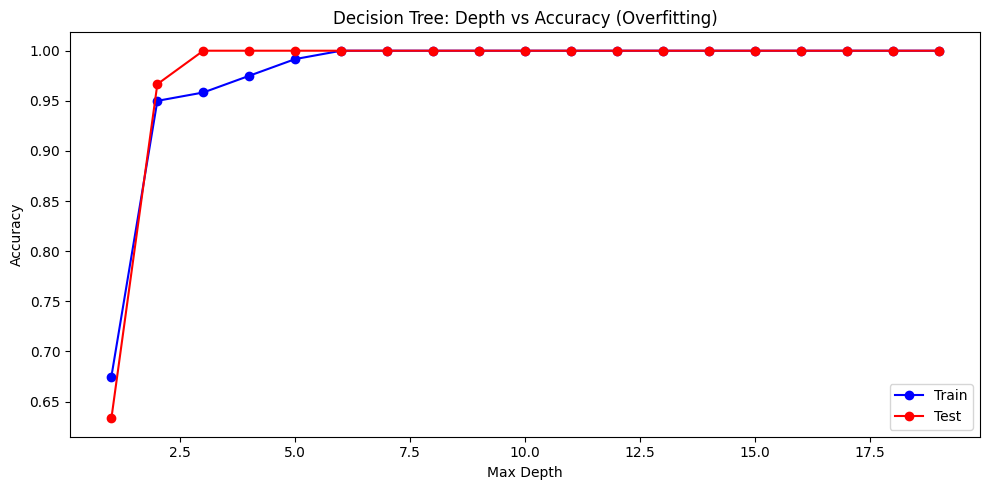

In [2]:
# Overfitting demonstration: depth vs accuracy
import numpy as np

depths = range(1, 20)
train_scores, test_scores = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'b-o', label='Train')
plt.plot(depths, test_scores, 'r-o', label='Test')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Depth vs Accuracy (Overfitting)')
plt.legend(); plt.tight_layout(); plt.show()

## 8.2 Random Forests (Bagging)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f'Random Forest accuracy: {rf.score(X_test, y_test):.4f}')
print(f'OOB score: {RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42).fit(cancer.data, cancer.target).oob_score_:.4f}')

Random Forest accuracy: 0.9649


OOB score: 0.9613


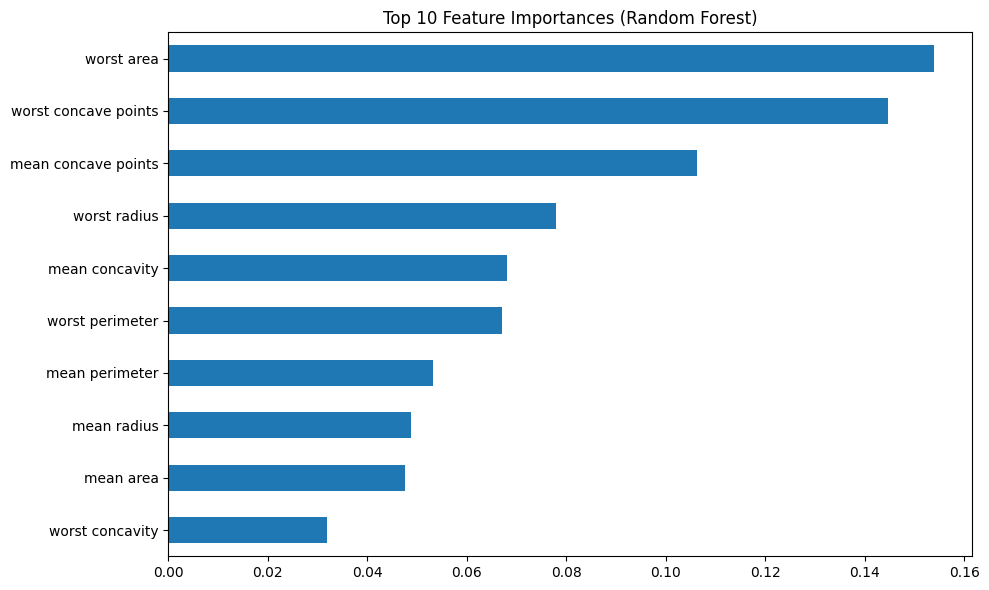

In [4]:
# Feature importance
import pandas as pd

importances = pd.Series(rf.feature_importances_, index=cancer.feature_names)
top_features = importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout(); plt.show()

## 8.3 Gradient Boosting

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
print(f'Gradient Boosting accuracy: {gb.score(X_test, y_test):.4f}')

# HistGradientBoosting (faster, handles missing values)
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(max_iter=100, random_state=42)
hgb.fit(X_train, y_train)
print(f'HistGradientBoosting accuracy: {hgb.score(X_test, y_test):.4f}')

Gradient Boosting accuracy: 0.9561


HistGradientBoosting accuracy: 0.9737


## 8.4 Comparing Ensemble Methods

In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

models = [
    ('Decision Tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
]

results = []
for name, model in models:
    scores = cross_val_score(model, cancer.data, cancer.target, cv=5)
    results.append({'Model': name, 'Mean Acc': round(scores.mean(), 4), 'Std': round(scores.std(), 4)})

pd.DataFrame(results).sort_values('Mean Acc', ascending=False)

,Model,Mean Acc,Std
4,AdaBoost,0.9772,0.0105
3,Gradient Boosting,0.9631,0.0210
2,Extra Trees,0.9614,0.0204
1,Random Forest,0.9561,0.0228
0,Decision Tree,0.9191,0.0180


## 8.5 Hyperparameter Tuning for Random Forests

In [7]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
random_search = RandomizedSearchCV(rf, param_dist, n_iter=20, cv=5, random_state=42, n_jobs=-1)
random_search.fit(cancer.data, cancer.target)

print('Best params:', random_search.best_params_)
print('Best score:', round(random_search.best_score_, 4))

Best params: {'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': None}
Best score: 0.9631


## 🔑 Key Takeaways

- **Decision trees** are interpretable but overfit easily — control with `max_depth` and `min_samples_split`.
- **Random Forests** reduce overfitting through bagging + random feature selection. Great all-around choice.
- **Gradient Boosting** sequentially corrects errors — often the highest accuracy but slower to train.
- `feature_importances_` provides a simple way to understand which features drive predictions.
- Tree-based models **do not require feature scaling** — a key advantage over SVMs and KNN.
- Use `RandomizedSearchCV` for large hyperparameter spaces — faster than `GridSearchCV`.
